# Advanced Training with KoopmanGraph

It assumes the encode → Koopman step → decode workflow from [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); this notebook is a cookbook of `fit()` knobs that control that training loop.

This notebook is a **power-user guide** to ``GraphKoopmanModel.fit``.

Training objectives regularize multi-step consistency of the linear latent map $z \leftarrow z K^{\top}$.

It focuses on options that help you scale and debug training beyond the default
single-sequence, single-origin, fixed learning-rate loop.

We use the fast synthetic benchmark so experiments stay reproducible. For domain
context see:

- [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) — basic workflow
- [`08_loss_stability.ipynb`](08_loss_stability.ipynb) — loss weights, ``loss_weight_schedule``, and operator stability
- [`03_traffic_network.ipynb`](03_traffic_network.ipynb) — windowed mini-batching on METR-LA


## Topics covered

| Topic | `fit` knobs |
|-------|-------------|
| Debugging composite objectives | per-term ``FitHistory`` fields |
| Multi-step supervision coverage | ``rollout_start_indices``, ``rollout_starts_per_epoch`` |
| Convergence tuning | ``lr_scheduler`` |
| Multiple realizations of the same system | ``MultiTrajectory((trajectory_a, trajectory_b, ...))`` |
| Production-style recipe | validation, early stopping, best-epoch restore |

Windowed mini-batch training (``window_length``, ``batch_size``) is demonstrated on
METR-LA in [`03_traffic_network.ipynb`](03_traffic_network.ipynb).

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch.optim.lr_scheduler import StepLR

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, MultiTrajectory
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.training import FitHistory, constant_loss_weights

NUM_TIMESTEPS = 24 if os.environ.get("PYTEST_CURRENT_TEST") else 40
# Keep CI short: this notebook runs many independent fit() demos.
EPOCHS = 8 if os.environ.get("PYTEST_CURRENT_TEST") else 60
ROLLOUT_HORIZON = 4 if os.environ.get("PYTEST_CURRENT_TEST") else 10
IN_CHANNELS = 3
HIDDEN = 32
LATENT = 32
MODEL_SEED = 0


def make_sequence(seed: int, *, noise_std: float = 0.02):
    return SyntheticDynamicGraphBenchmark.generate(
        num_nodes=20,
        num_timesteps=NUM_TIMESTEPS,
        in_channels=IN_CHANNELS,
        topology="path",
        seed=seed,
        initial_state="ones",
        decay_rate=0.97,
        diffusion_rate=0.25,
        noise_std=noise_std,
    )


train_sequence = make_sequence(seed=42)
holdout_sequence = make_sequence(seed=99)

# Shared by the multi-origin and random-origin rollout sections.
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=0.5,
    rollout=1.0,
)
EVAL_STARTS = [0, NUM_TIMESTEPS // 3, 2 * NUM_TIMESTEPS // 3]
EVAL_STARTS = [
    idx
    for idx in EVAL_STARTS
    if idx + ROLLOUT_HORIZON < holdout_sequence.num_timesteps
]

print(f"Training snapshots: {train_sequence.num_timesteps}")
print(f"Rollout horizon: {ROLLOUT_HORIZON}")


Training snapshots: 40
Rollout horizon: 10


## Helper functions

Model factory, rollout MSE, and per-term history plotting.


In [2]:
def build_model() -> GraphKoopmanModel:
    encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT)
    decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS)
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT,
        time_step=0.1,
    )


def rollout_mse(
    model: GraphKoopmanModel,
    sequence,
    *,
    start_idx: int,
    steps: int,
) -> float:
    model.eval()
    with torch.no_grad():
        preds = model.predict(sequence[start_idx], steps=steps)
    truth = sequence[start_idx + 1 : start_idx + 1 + steps]
    per_step = [torch.mean((p.x - t.x) ** 2) for p, t in zip(preds, truth, strict=True)]
    return torch.stack(per_step).mean().item()


def plot_term_history(history: FitHistory, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.reconstruction_loss, label="reconstruction")
    ax.plot(history.forward_loss, label="forward")
    ax.plot(history.rollout_loss, label="rollout")
    ax.plot(history.loss, label="weighted total", linewidth=2, linestyle="--")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()


## Per-term loss history

``FitHistory.loss`` is the **weighted** training objective. When you combine
reconstruction, consistency, and rollout terms, inspect the unweighted
``reconstruction_loss``, ``forward_loss``, and ``rollout_loss`` curves to see
which component is driving training. On this easy synthetic path, forward
consistency often sits near zero while reconstruction and rollout dominate the
early descent — that is expected, not a missing term.


Final weighted loss: 0.006907 | recon: 0.004309 | rollout: 0.001952


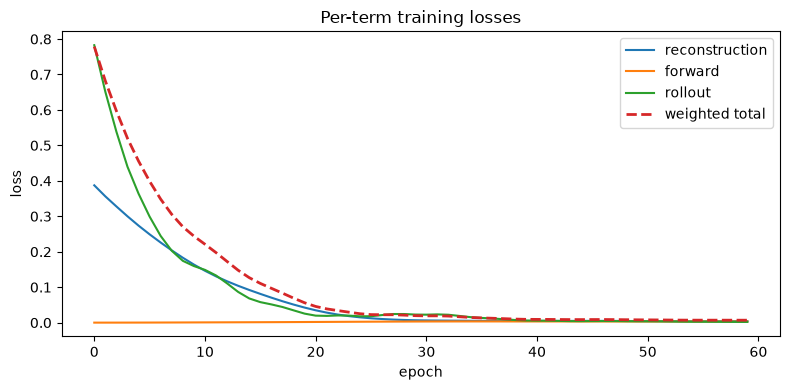

In [3]:
torch.manual_seed(MODEL_SEED)
debug_model = build_model()
debug_history = debug_model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=constant_loss_weights(
        reconstruction=1.0,
        forward=0.5,
        rollout=0.5,
    ),
    rollout_horizon=ROLLOUT_HORIZON,
)

print(
    f"Final weighted loss: {debug_history.loss[-1]:.6f} | "
    f"recon: {debug_history.reconstruction_loss[-1]:.6f} | "
    f"rollout: {debug_history.rollout_loss[-1]:.6f}"
)
plot_term_history(debug_history, "Per-term training losses")

## Rollout start indices

By default, rollout loss is computed from **snapshot 0 only**
(``rollout_start_indices=None`` → ``[0]``). That can under-supervise mid-trajectory
dynamics. Setting ``rollout_start_indices="all"`` includes every valid origin
for the chosen ``rollout_horizon``.

The origin-``[0]`` model may still win rollouts **starting at** ``t=0`` because
that is the only origin it supervises. ``"all"`` trades a small loss there for
lower error mid- and late-trajectory, where multi-origin supervision matters most.

start= 0 | origin [0] MSE=0.002395 | all origins MSE=0.003748
start=13 | origin [0] MSE=0.003662 | all origins MSE=0.002112
start=26 | origin [0] MSE=0.006361 | all origins MSE=0.003087


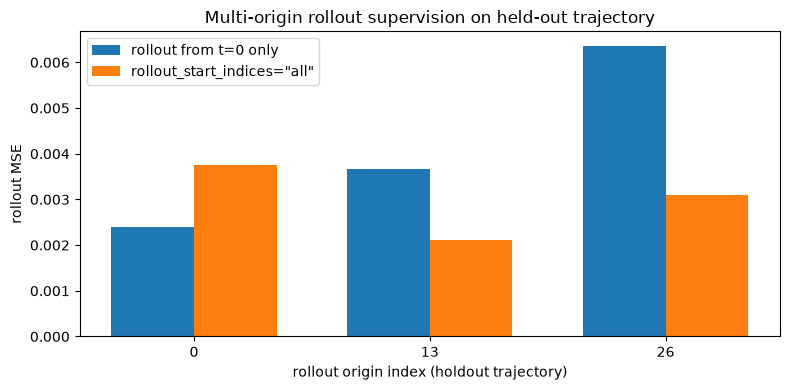

In [4]:
torch.manual_seed(MODEL_SEED)
origin_zero_model = build_model()
origin_zero_model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=ROLLOUT_HORIZON,
    rollout_start_indices=None,
)

torch.manual_seed(MODEL_SEED)
all_origins_model = build_model()
all_origins_model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=ROLLOUT_HORIZON,
    rollout_start_indices="all",
)

origin_zero_scores = [
    rollout_mse(origin_zero_model, holdout_sequence, start_idx=idx, steps=ROLLOUT_HORIZON)
    for idx in EVAL_STARTS
]
all_origins_scores = [
    rollout_mse(all_origins_model, holdout_sequence, start_idx=idx, steps=ROLLOUT_HORIZON)
    for idx in EVAL_STARTS
]
all_origins_mid_mse = all_origins_scores[len(EVAL_STARTS) // 2]

for idx, z_score, a_score in zip(EVAL_STARTS, origin_zero_scores, all_origins_scores, strict=True):
    print(
        f"start={idx:2d} | origin [0] MSE={z_score:.6f} | "
        f"all origins MSE={a_score:.6f}"
    )

x = torch.arange(len(EVAL_STARTS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, origin_zero_scores, width, label="rollout from t=0 only")
ax.bar(x + width / 2, all_origins_scores, width, label='rollout_start_indices="all"')
ax.set_xticks(x.tolist())
ax.set_xticklabels([str(idx) for idx in EVAL_STARTS])
ax.set_xlabel("rollout origin index (holdout trajectory)")
ax.set_ylabel("rollout MSE")
ax.set_title("Multi-origin rollout supervision on held-out trajectory")
ax.legend()
fig.tight_layout()
plt.show()


## Random rollout origins per epoch

On long trajectories, ``rollout_start_indices="all"`` can be expensive.
``rollout_starts_per_epoch`` samples a fixed number of random origins each epoch.
``rollout_start_seed`` makes that sampling reproducible. On this short synthetic
trajectory, mid-start holdout MSE for random origins is often *comparable* to
``"all"`` (sometimes slightly better) — the point is cheaper stochastic coverage,
not a guaranteed lower error than full multi-origin supervision.


In [5]:
torch.manual_seed(MODEL_SEED)
random_origins_model = build_model()
random_history = random_origins_model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=ROLLOUT_HORIZON,
    rollout_starts_per_epoch=3 if os.environ.get("PYTEST_CURRENT_TEST") else 6,
    rollout_start_seed=42,
)

mid_start = EVAL_STARTS[len(EVAL_STARTS) // 2]
random_mid_mse = rollout_mse(
    random_origins_model,
    holdout_sequence,
    start_idx=mid_start,
    steps=ROLLOUT_HORIZON,
)
print(f"Random-origin training: final loss={random_history.loss[-1]:.6f}")
print(f"Mid-trajectory holdout rollout MSE (start={mid_start}): {random_mid_mse:.6f}")
if "all_origins_mid_mse" in globals():
    print(
        f'Compare to rollout_start_indices="all" mid MSE: '
        f"{all_origins_mid_mse:.6f}"
    )


Random-origin training: final loss=0.008172
Mid-trajectory holdout rollout MSE (start=13): 0.001958
Compare to rollout_start_indices="all" mid MSE: 0.002112


## Learning-rate scheduler

Pass a **factory** ``lr_scheduler=lambda optim: ...`` that builds a standard
PyTorch scheduler from the optimizer created inside ``fit``. The scheduler
steps once per epoch after the optimizer update. Vertical markers below show
when ``StepLR`` fires; on a short synthetic run most of the loss drop can
occur *before* the first decay, so treat the plot as an API demo rather than
proof that scheduling was required here.


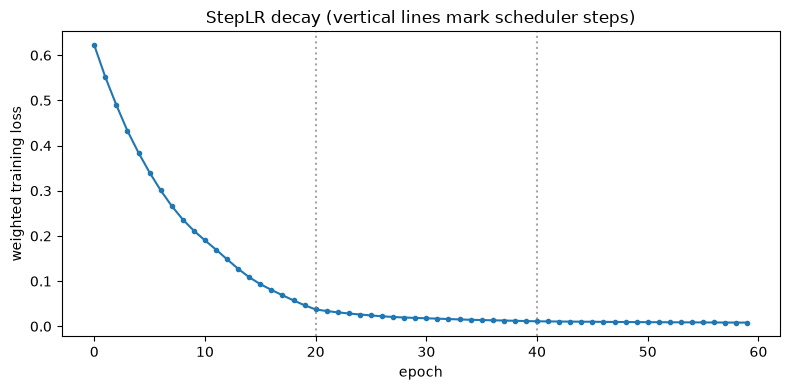

In [6]:
torch.manual_seed(MODEL_SEED)
scheduled_model = build_model()
scheduler_step = 8 if os.environ.get("PYTEST_CURRENT_TEST") else 20
scheduled_history = scheduled_model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=constant_loss_weights(reconstruction=1.0, forward=0.5, rollout=0.3),
    rollout_horizon=ROLLOUT_HORIZON,
    lr_scheduler=lambda optim: StepLR(optim, step_size=scheduler_step, gamma=0.5),
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scheduled_history.loss, marker="o", markersize=3)
for step in range(scheduler_step, EPOCHS, scheduler_step):
    ax.axvline(step, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("epoch")
ax.set_ylabel("weighted training loss")
ax.set_title("StepLR decay (vertical lines mark scheduler steps)")
fig.tight_layout()
plt.show()

## Multi-trajectory training

When you have **multiple simulation runs** or experimental replicates of the
same graph system, wrap them in ``MultiTrajectory`` (a bare list of
``GraphSnapshotSequence`` objects is rejected). ``fit`` averages losses across
trajectories before each optimizer step. On this short synthetic holdout the
MSE gap can be small; the point is the correct multi-replicate input path.


In [7]:
trajectory_seeds = (0, 1, 2)
training_trajectories = [make_sequence(seed=seed) for seed in trajectory_seeds]

torch.manual_seed(MODEL_SEED)
single_traj_model = build_model()
single_traj_model.fit(
    training_trajectories[0],
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=constant_loss_weights(reconstruction=1.0, forward=0.5, rollout=0.3),
    rollout_horizon=ROLLOUT_HORIZON,
)

torch.manual_seed(MODEL_SEED)
multi_traj_model = build_model()
multi_traj_model.fit(
    MultiTrajectory(tuple(training_trajectories)),
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=constant_loss_weights(reconstruction=1.0, forward=0.5, rollout=0.3),
    rollout_horizon=ROLLOUT_HORIZON,
)

single_holdout_mse = rollout_mse(
    single_traj_model,
    holdout_sequence,
    start_idx=0,
    steps=ROLLOUT_HORIZON,
)
multi_holdout_mse = rollout_mse(
    multi_traj_model,
    holdout_sequence,
    start_idx=0,
    steps=ROLLOUT_HORIZON,
)

print(f"Single-trajectory holdout rollout MSE: {single_holdout_mse:.6f}")
print(f"Multi-trajectory holdout rollout MSE:  {multi_holdout_mse:.6f}")


Single-trajectory holdout rollout MSE: 0.001978
Multi-trajectory holdout rollout MSE:  0.001829


## Combined recipe

A practical configuration for longer projects: multiple training trajectories,
validation monitoring, learning-rate decay, multi-origin rollout supervision,
and best-epoch weight restoration.

We use a **noisier validation trajectory** (``noise_std=0.08`` vs ``0.02`` on
training data) to mimic mild train/validation shift. On this easy synthetic
benchmark that makes validation-based early stopping and ``restore_best_weights``
visible; when train and validation come from the same distribution, training
may simply run for the full epoch budget without stopping early.

Completed epochs: 26 / 100
Stopped early: True
Best epoch: 17, best val loss: 0.047321
Final val loss: 0.049974
Restored best-epoch weights: 0.047321 (epoch 17)


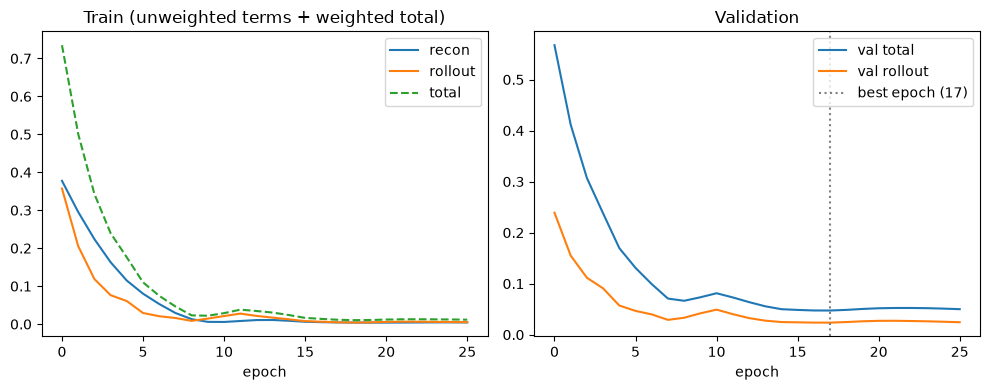

In [8]:
RECIPE_EPOCHS = EPOCHS if os.environ.get("PYTEST_CURRENT_TEST") else 100
val_sequence = make_sequence(seed=7, noise_std=0.08)
recipe_trajectories = [make_sequence(seed=seed) for seed in (10, 11)]

torch.manual_seed(MODEL_SEED)
recipe_model = build_model()
recipe_history = recipe_model.fit(
    MultiTrajectory(tuple(recipe_trajectories)),
    validation_sequence=val_sequence,
    epochs=RECIPE_EPOCHS,
    lr=3e-3,
    loss_weights=constant_loss_weights(
        reconstruction=1.0,
        forward=0.5,
        rollout=1.0,
    ),
    rollout_horizon=ROLLOUT_HORIZON,
    rollout_start_indices="all",
    lr_scheduler=lambda optim: StepLR(
        optim,
        step_size=8 if os.environ.get("PYTEST_CURRENT_TEST") else 15,
        gamma=0.5,
    ),
    early_stopping_patience=5 if os.environ.get("PYTEST_CURRENT_TEST") else 8,
    early_stopping_monitor="val",
    restore_best_weights=True,
)

print(f"Completed epochs: {recipe_history.epochs} / {RECIPE_EPOCHS}")
print(f"Stopped early: {recipe_history.stopped_early}")
print(f"Best epoch: {recipe_history.best_epoch}, best val loss: {recipe_history.best_loss:.6f}")
if recipe_history.val_loss is not None:
    print(f"Final val loss: {recipe_history.val_loss[-1]:.6f}")
    if recipe_history.best_epoch is not None:
        print(
            "Restored best-epoch weights: "
            f"{recipe_history.val_loss[recipe_history.best_epoch]:.6f} "
            f"(epoch {recipe_history.best_epoch})"
        )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(recipe_history.reconstruction_loss, label="recon")
axes[0].plot(recipe_history.rollout_loss, label="rollout")
axes[0].plot(recipe_history.loss, label="total", linestyle="--")
axes[0].set_title("Train (unweighted terms + weighted total)")
axes[0].set_xlabel("epoch")
axes[0].legend()

if recipe_history.val_loss is not None:
    axes[1].plot(recipe_history.val_loss, label="val total")
    axes[1].plot(recipe_history.val_rollout_loss, label="val rollout")
    if recipe_history.best_epoch is not None:
        axes[1].axvline(
            recipe_history.best_epoch,
            color="gray",
            linestyle=":",
            label=f"best epoch ({recipe_history.best_epoch})",
        )
    axes[1].set_title("Validation")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

fig.tight_layout()
plt.show()


## Windowed mini-batch training

For long real-world sequences, use ``window_length`` and ``batch_size`` to
perform **multiple optimizer updates per epoch** on fixed-length temporal
windows. See the throughput benchmark in
[`03_traffic_network.ipynb`](03_traffic_network.ipynb).

```python
history = model.fit(
    data_sequence,
    window_length=12,
    batch_size=8,
    windows_per_epoch=64,
    window_seed=42,
)
```

## Takeaways

| Parameter | When to use it |
|-----------|----------------|
| Per-term ``FitHistory`` | Debugging composite loss weights |
| ``rollout_start_indices="all"`` | Improve mid-trajectory multi-step accuracy |
| ``rollout_starts_per_epoch`` | Stochastic coverage on long sequences |
| ``lr_scheduler`` | Attach a PyTorch LR schedule inside ``fit`` |
| ``MultiTrajectory((traj_a, traj_b, ...))`` | Multiple replicates of the same graph system |
| ``validation_sequence`` + ``restore_best_weights`` | Credible holdout monitoring |

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the minimal train loop.
- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for windowed mini-batch throughput on METR-LA.
- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) for ``loss_weight_schedule`` and operator stability.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
